# Plot Malina Oceanographic Campaign CTD profiles

In [3]:
import numpy as np
import xarray as xr
import pandas as pd
import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import gsw
import os

In [4]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:38657")
client

<Client: 'tcp://127.0.0.1:38657' processes=8 threads=32, memory=123.95 GiB>

In [ ]:
# load CSV
df = pd.read_csv('/Users/mzahn/data/Mackenzie_obs/Massicotte_et_al_2020/ctd.csv', sep=",")
df['start_date_time_utc'] = pd.to_datetime(df['start_date_time_utc'])

In [196]:
# Rename columns for convenience
df = df.rename(columns={
    'start_date_time_utc': 'time',
    'initial_latitude_deg': 'lat',
    'initial_longitude_deg': 'lon',
    'max_depth_m': 'max_depth',
    'pres': 'pressure',
    'temp': 'temperature',
    'sal': 'salinity',
    'sigthe': 'potential_dens'
})

# Build xarray Dataset
# We want dims = (time, pressure)
# But pressure varies per cast, so we group by each timestamp

ds_list = []

for t, g in df.groupby('time'):
    g = g.sort_values('pressure')  # ensure ordered

    # Create a dataset for this cast
    dsi = xr.Dataset(
        {
            'temperature': ('pressure', g['temperature'].values),
            'salinity': ('pressure', g['salinity'].values),
            'potential_dens': ('pressure', g['potential_dens'].values),
        },
        coords={
            'pressure': g['pressure'].values,
            'time': np.datetime64(t),
            'cast_number': g['cast_number'].iloc[0],
            'lat': g['lat'].iloc[0],
            'lon': g['lon'].iloc[0],
            'max_depth': g['max_depth'].iloc[0],
        }
    )

    ds_list.append(dsi)

# combine all casts along *time* dimension
ds = xr.concat(ds_list, dim='time')
ctd_ds = ds.sortby('time')

ctd_ds

/tmp/ipykernel_53706/42759460.py:31: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  'time': np.datetime64(t),


<xarray.Dataset> Size: 7MB
Dimensions:         (time: 165, pressure: 1804)
Coordinates:
  * pressure        (pressure) int64 14kB 3 4 5 6 7 ... 1802 1803 1804 1805 1806
  * time            (time) datetime64[us] 1kB 2009-07-31T21:08:31 ... 2009-08...
    cast_number     (time) int64 1kB 25 26 27 28 29 30 ... 187 188 189 190 191
    lat             (time) float64 1kB 70.18 70.18 70.18 ... 71.74 71.72 71.71
    lon             (time) float64 1kB -133.6 -133.6 -133.6 ... -130.8 -130.8
    max_depth       (time) float64 1kB 46.05 35.88 35.73 ... 514.4 297.2 300.0
Data variables:
    temperature     (time, pressure) float64 2MB 5.022 5.172 4.987 ... nan nan
    salinity        (time, pressure) float64 2MB nan 27.23 27.33 ... nan nan nan
    potential_dens  (time, pressure) float64 2MB nan 21.5 21.6 ... nan nan nan

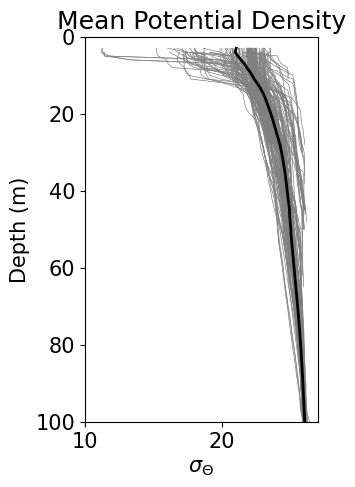

In [299]:
plt.rcParams['font.size'] = 15
ctd_ds.potential_dens.plot(hue='time',y='pressure',c='gray',linewidth=0.5,\
                            add_legend=False,label='All Profiles',figsize=[3,5])
ctd_ds.potential_dens.mean('time').plot(y='pressure',c='k',linewidth=2,label='Mean')
plt.ylim(100,0)
plt.xlim(10,27)
plt.title('Mean Potential Density')
plt.xlabel(r'$\sigma_{\Theta}$');
plt.ylabel('Depth (m)');

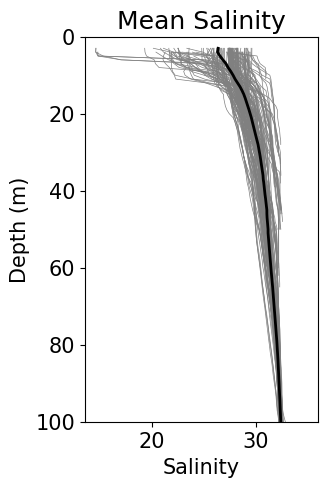

In [301]:
plt.rcParams['font.size'] = 15
ctd_ds.salinity.plot(hue='time',y='pressure',c='gray',linewidth=0.5,\
                            add_legend=False,label='All Profiles',figsize=[3,5])
ctd_ds.salinity.mean('time').plot(y='pressure',c='k',linewidth=2,label='Mean')
plt.ylim(100,0)
# plt.xlim(10,27)
plt.title('Mean Salinity')
plt.xlabel('Salinity');
plt.ylabel('Depth (m)');

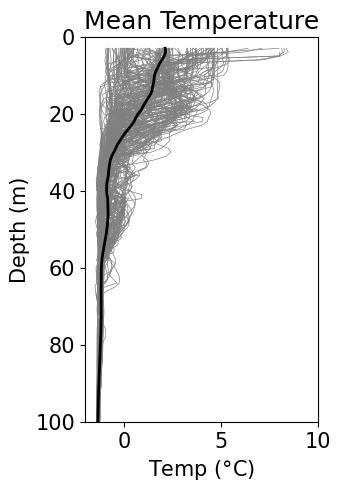

In [309]:
plt.rcParams['font.size'] = 15
ctd_ds.temperature.plot(hue='time',y='pressure',c='gray',linewidth=0.5,\
                            add_legend=False,label='All Profiles',figsize=[3,5])
ctd_ds.temperature.mean('time').plot(y='pressure',c='k',linewidth=2,label='Mean')
plt.ylim(100,0)
plt.xlim(-2,10)
plt.title('Mean Temperature')
plt.xlabel(r'Temp ($\degree$C)');
plt.ylabel('Depth (m)');

In [200]:
# open bathymetry
bathy_ds = xr.open_dataset('/Users/mzahn/data/GEBCO/GEBCO_2023.nc')
bathy_beaufort = bathy_ds.elevation.sel(lat=slice(68,80,5),lon=slice(-170,-120,5))

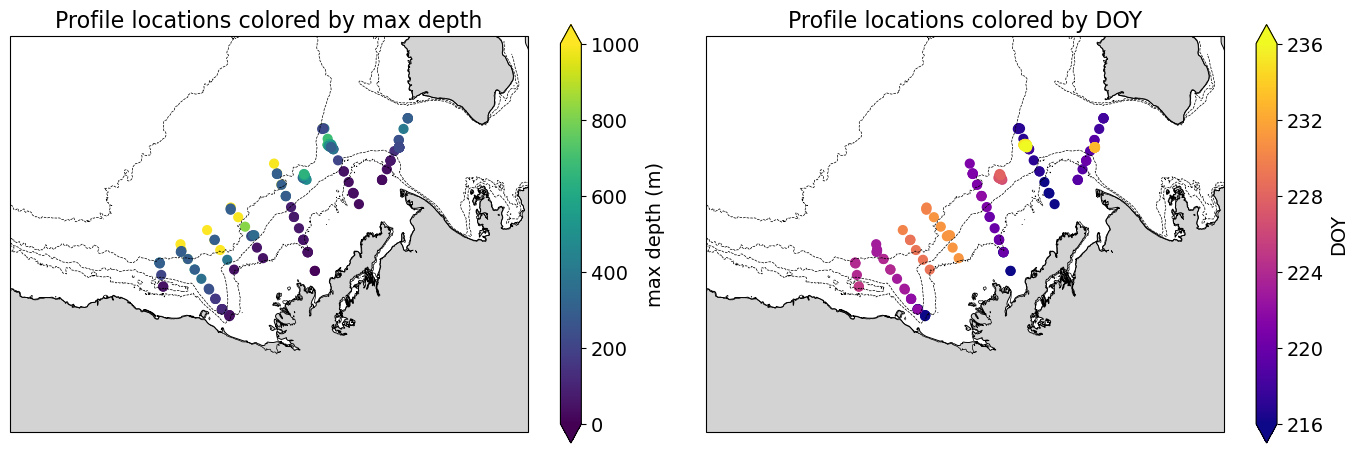

In [319]:
plt.rcParams['font.size'] = 14

# --- extract profile-level coords/vars ---
lats = ctd_ds['lat'].values
lons = ctd_ds['lon'].values
max_depths = ctd_ds['max_depth'].values

# convert times to pandas datetimes then to day-of-year (DOY)
times = pd.to_datetime(ds['time'].values)
doy = times.dayofyear.astype(int)   # integers 1..365 (or 366)

# --- projection and figure ---
proj = ccrs.NorthPolarStereo(central_longitude=-150)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': proj})

for ax in axes:
    ax.set_extent([-148, -125, 68, 73], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.7)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    # ax.gridlines(draw_labels=False, linewidth=0.3, color='gray')

    # add isobaths
    bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# --- left: colored by max depth ---
sc1 = axes[0].scatter(
    lons, lats,
    c=max_depths,vmin=0,vmax=1000,
    cmap='viridis',
    s=40,
    transform=ccrs.PlateCarree()
)
axes[0].set_title('Profile locations colored by max depth', fontsize=16)
cb1 = fig.colorbar(sc1, ax=axes[0], orientation='vertical', shrink=0.75,extend='both')
cb1.set_label("max depth (m)", fontsize=14)

# --- right: colored by DOY ---
sc2 = axes[1].scatter(
    lons, lats,
    c=doy,vmin=216,vmax=236,
    cmap='plasma',
    s=40,
    transform=ccrs.PlateCarree()
)
axes[1].set_title('Profile locations colored by DOY', fontsize=16)

cb2 = fig.colorbar(sc2, ax=axes[1], orientation='vertical', shrink=0.75,extend='both')
cb2.set_label("DOY", fontsize=14)

# make colorbar ticks integer-ish (choose up to 6 ticks across the DOY range)
dmin, dmax = doy.min(), doy.max()
n_ticks = 6
ticks = np.linspace(216, 236, n_ticks).round().astype(int)
cb2.set_ticks(ticks)
cb2.set_ticklabels([str(t) for t in ticks])

plt.tight_layout()
plt.show()

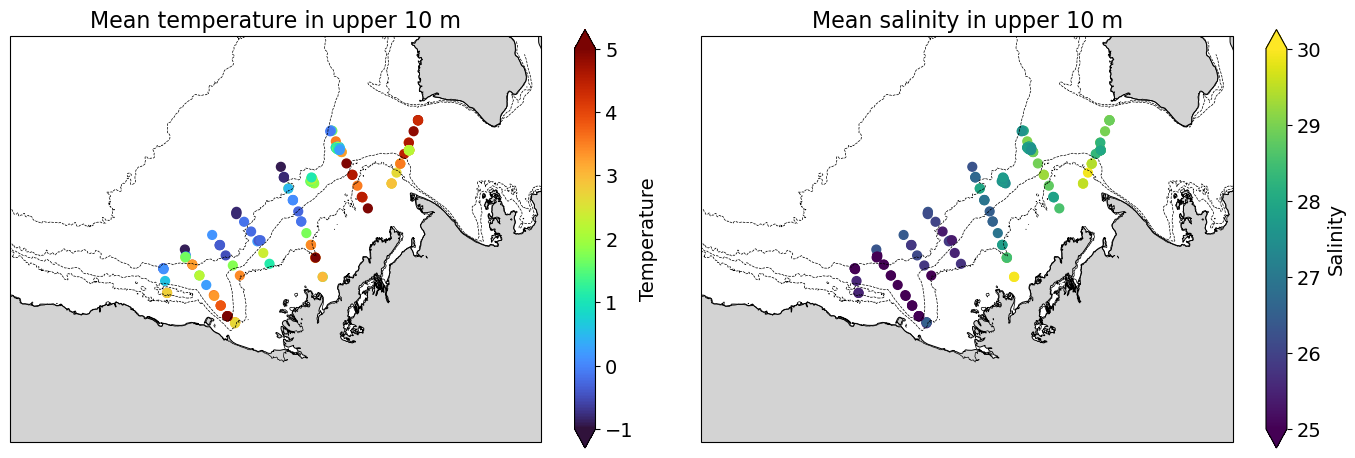

In [249]:
plt.rcParams['font.size'] = 14

# --- extract profile-level coords/vars ---
lats = ctd_ds['lat'].values
lons = ctd_ds['lon'].values
temp = ctd_ds['temperature'].sel(pressure=slice(0,10)).mean('pressure').values
salt = ctd_ds['salinity'].sel(pressure=slice(0,10)).mean('pressure').values

# --- projection and figure ---
proj = ccrs.NorthPolarStereo(central_longitude=-150)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': proj})

for ax in axes:
    ax.set_extent([-148, -125, 68, 73], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.7)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    # ax.gridlines(draw_labels=False, linewidth=0.3, color='gray')

    # add isobaths
    bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# --- left: colored by max depth ---
sc1 = axes[0].scatter(
    lons, lats,
    c=temp,vmin=-1,vmax=5,
    cmap='turbo',
    s=40,
    transform=ccrs.PlateCarree()
)
axes[0].set_title('Mean temperature in upper 10 m', fontsize=16)
cb1 = fig.colorbar(sc1, ax=axes[0], orientation='vertical', shrink=0.75,extend='both')
cb1.set_label("Temperature", fontsize=14)

# --- right: colored by DOY ---
sc2 = axes[1].scatter(
    lons, lats,
    c=salt,vmin=25,vmax=30,
    cmap='viridis',
    s=40,
    transform=ccrs.PlateCarree()
)
axes[1].set_title('Mean salinity in upper 10 m', fontsize=16)

cb2 = fig.colorbar(sc2, ax=axes[1], orientation='vertical', shrink=0.75,extend='both')
cb2.set_label("Salinity", fontsize=14)

plt.tight_layout()
plt.show()

## Compute MLD

In [212]:
def compute_mld(ctd_ds, rho_thresh=0.1):

    # Broadcast latitude + longitude to match (time, z)
    lat2d = ctd_ds.lat.broadcast_like(ctd_ds.salinity)
    lon2d = ctd_ds.lon.broadcast_like(ctd_ds.salinity)

    mld_list = []

    # Loop profiles
    for t in ctd_ds.time.values:
        # print(t)
        rho_profile = ctd_ds.potential_dens.sel(time=t)
        depth_profile = ctd_ds.pressure  # same for all times

        # reference density at **uppermost valid measurement**
        valid_idx = np.where(~np.isnan(rho_profile.values))[0]
        if len(valid_idx) == 0:
            mld_list.append(np.nan)
            continue

        rho0 = rho_profile.isel(pressure=valid_idx[0]).values

        # density anomaly relative to surface
        drho = rho_profile - rho0

        # first z where drho >= threshold
        idx = np.argmax(drho.values >= rho_thresh)

        if drho[idx] >= rho_thresh:
            mld = depth_profile.isel(pressure=idx).item()
        else:
            mld = np.nan  # no mixed layer depth found

        mld_list.append(mld)

    # Return as DataArray
    return xr.DataArray(
        mld_list,
        coords={'time': ctd_ds.time},
        dims=['time'],
        name='MLD',
        attrs={'units': 'm', 'long_name': 'Mixed Layer Depth (0.1 kg/m^3 threshold)'}
    )

In [214]:
mld_da = compute_mld(ctd_ds, rho_thresh=0.1)

In [245]:
mld_da

<xarray.DataArray 'MLD' (time: 165)> Size: 1kB
array([ 5.,  6.,  7.,  5.,  5.,  5.,  5.,  6.,  5.,  5.,  5.,  5.,  5.,
        8.,  9.,  5.,  9.,  8., 12., 12.,  9.,  8., 12., 10., 13., 11.,
       11.,  9., 12.,  7., 11.,  7., 11., 17.,  5., 14., 10., 11.,  6.,
        4.,  6.,  9.,  6., 12.,  9.,  7.,  7.,  9.,  8., 10.,  9.,  8.,
        8.,  4.,  9., 13., nan,  7.,  7.,  6.,  5., 11., 10.,  8.,  9.,
        8.,  6.,  7.,  6.,  5.,  5.,  4.,  5.,  5.,  5.,  5.,  8.,  6.,
        6.,  4.,  5.,  5.,  4.,  4.,  4.,  9.,  8.,  9., 10.,  8., 10.,
        5.,  6.,  7., 10.,  8.,  6.,  5.,  7.,  8., 12.,  8.,  9., 11.,
        7.,  4.,  4.,  7.,  5., 10.,  8.,  7.,  6.,  8.,  5.,  6., 10.,
        5.,  7.,  8.,  7.,  7., 12., 10., 10.,  9.,  8.,  6.,  7.,  9.,
       12., 11.,  7.,  5., 12., 14., 13., 12., 10., 11., 10., 11.,  9.,
       12., 11., 10.,  7., 11., 10.,  5.,  9.,  4., 10.,  5., 12.,  6.,
        8.,  6.,  9.,  5.,  6.,  6.,  7., 13.,  8.])
Coordinates:
  * time     (time) datetime64[us] 1kB 2009-07-31T21:08:31 ... 2009-08-24T14:...
Attributes:
    units:      m
    long_name:  Mixed Layer Depth (0.1 kg/m^3 threshold)

### Plot density difference (Stratification) and MLD

In [262]:
delta_rho = ctd_ds.sel(pressure=20).potential_dens - ctd_ds.sel(pressure=5).potential_dens

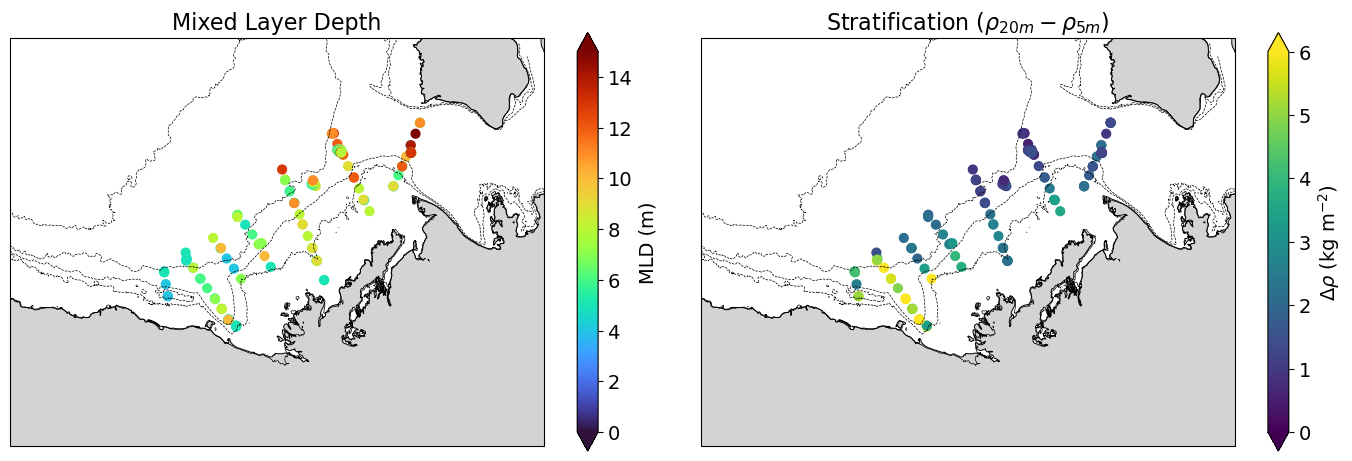

In [278]:
plt.rcParams['font.size'] = 14

# --- extract profile-level coords/vars ---
lats = ctd_ds['lat'].values
lons = ctd_ds['lon'].values
temp = ctd_ds['temperature'].sel(pressure=slice(0,10)).mean('pressure').values
salt = ctd_ds['salinity'].sel(pressure=slice(0,10)).mean('pressure').values

# --- projection and figure ---
proj = ccrs.NorthPolarStereo(central_longitude=-150)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': proj})

for ax in axes:
    ax.set_extent([-148, -125, 68, 73], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.7)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    # ax.gridlines(draw_labels=False, linewidth=0.3, color='gray')

    # add isobaths
    bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# --- left: colored by max depth ---
sc1 = axes[0].scatter(
    lons, lats,
    c=mld_da,vmin=0,vmax=15,
    cmap='turbo',
    s=40,
    transform=ccrs.PlateCarree()
)
axes[0].set_title('Mixed Layer Depth', fontsize=16)
cb1 = fig.colorbar(sc1, ax=axes[0], orientation='vertical', shrink=0.75,extend='both')
cb1.set_label("MLD (m)", fontsize=14)

# --- right: colored by DOY ---
sc2 = axes[1].scatter(
    lons, lats,
    c=delta_rho,vmin=0,vmax=6,
    cmap='viridis',
    s=40,
    transform=ccrs.PlateCarree()
)
axes[1].set_title(r'Stratification ($\rho_{20m} - \rho_{5m}$)', fontsize=16)

cb2 = fig.colorbar(sc2, ax=axes[1], orientation='vertical', shrink=0.75,extend='both')
cb2.set_label(r"$\Delta\rho$ (kg m$^{-2}$)", fontsize=14)

plt.tight_layout()
plt.show()

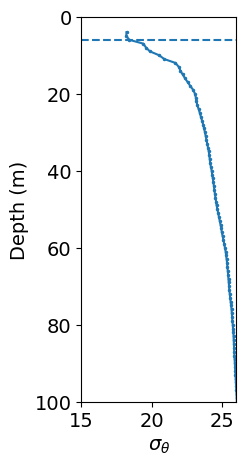

In [455]:
i=68
mld_tmp = mld_da.isel(time=i)

ctd_ds.potential_dens.isel(time=i).plot(add_legend=False,y='pressure',marker='.',markersize=3,figsize=[2,5])
plt.axhline(y=mld_tmp,linestyle='dashed')
plt.xlim(15,26)
# plt.xlim(15,30)
plt.xlabel(r'$\sigma_{\theta}$')
plt.ylabel('Depth (m)')
plt.title("")
plt.ylim(100,0);

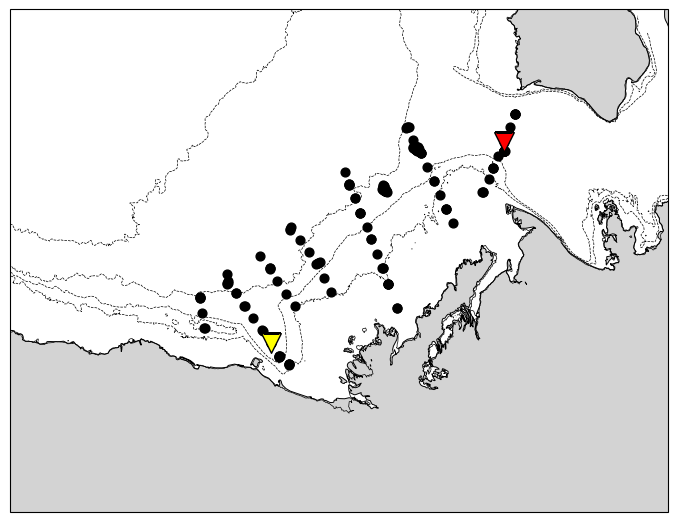

In [520]:
plt.rcParams['font.size'] = 14

# --- extract profile-level coords/vars ---
lats = ctd_ds['lat'].values
lons = ctd_ds['lon'].values
salt = ctd_ds['salinity'].sel(pressure=slice(0,10)).mean('pressure').values

# --- projection and figure ---
proj = ccrs.NorthPolarStereo(central_longitude=-150)
fig, ax = plt.subplots(1, 1, figsize=(7, 6), subplot_kw={'projection': proj})

ax.set_extent([-148, -125, 68, 73], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.7)
ax.add_feature(cfeature.LAND, facecolor='lightgray')
# ax.gridlines(draw_labels=False, linewidth=0.3, color='gray')
# add isobaths
bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# --- left: colored by max depth ---
sc1 = ax.scatter(
    lons, lats,c='k',
    s=40,
    transform=ccrs.PlateCarree()
)
ax.scatter(ctd_ds.isel(time=65).lon, ctd_ds.isel(time=65).lat, marker='v', color='yellow', edgecolor='k', s=200,transform=ccrs.PlateCarree())
ax.scatter(ctd_ds.isel(time=35).lon, ctd_ds.isel(time=35).lat, marker='v', color='r',edgecolor='k', s=200,transform=ccrs.PlateCarree())

plt.tight_layout()
plt.show()

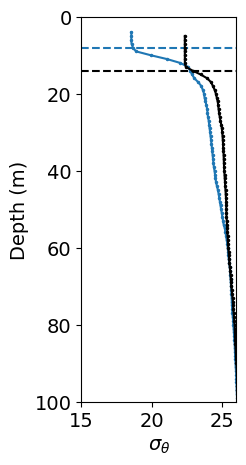

In [522]:
i=65
mld_tmp = mld_da.isel(time=i)
ctd_ds.potential_dens.isel(time=i).plot(add_legend=False,y='pressure',marker='.',markersize=3,figsize=[2,5])
plt.axhline(y=mld_tmp,linestyle='dashed')

i=35
mld_tmp = mld_da.isel(time=i)
ctd_ds.potential_dens.isel(time=i).plot(add_legend=False,y='pressure',marker='.',color='k',markersize=3)
plt.axhline(y=mld_tmp,color='k',linestyle='dashed')

plt.xlim(15,26)
# plt.xlim(15,30)
plt.xlabel(r'$\sigma_{\theta}$')
plt.ylabel('Depth (m)')
plt.title("")
plt.ylim(100,0);